In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = pd.read_csv('Carbon Emission.csv')
df = pd.DataFrame(data)
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [3]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

In [4]:
df.columns


Index(['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source',
       'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill',
       'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km',
       'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour',
       'How Many New Clothes Monthly', 'How Long Internet Daily Hour',
       'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission'],
      dtype='object')

In [5]:
df.shape

(10000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   3279 non-null   object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         10000 non-null  int64 
 13  Ho

In [7]:
df.describe()

,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300
std,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247
min,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000
25%,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000
50%,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000
75%,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000
max,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000


In [8]:
df.isnull().sum()

Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [9]:
df['Vehicle Type'] = df['Vehicle Type'].fillna('non vehicle')

In [10]:
df.isnull().sum()

Body Type                        0
Sex                              0
Diet                             0
How Often Shower                 0
Heating Energy Source            0
Transport                        0
Vehicle Type                     0
Social Activity                  0
Monthly Grocery Bill             0
Frequency of Traveling by Air    0
Vehicle Monthly Distance Km      0
Waste Bag Size                   0
Waste Bag Weekly Count           0
How Long TV PC Daily Hour        0
How Many New Clothes Monthly     0
How Long Internet Daily Hour     0
Energy efficiency                0
Recycling                        0
Cooking_With                     0
CarbonEmission                   0
dtype: int64

In [11]:
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,non vehicle,often,230,frequently,210,large,4,7,26,1,no,['metal'],"['stove', 'oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,non vehicle,often,114,rarely,9,extra large,3,9,38,5,no,['metal'],"['stove', 'microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,sometimes,['metal'],"['oven', 'microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,non vehicle,sometimes,157,rarely,74,medium,3,20,5,7,sometimes,"['paper', 'plastic', 'glass', 'metal']","['microwave', 'grill', 'airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,yes,['paper'],['oven'],4743


In [12]:
import ast

def clean_list_column(col):
    def clean_value(x):
        try:
            items = ast.literal_eval(x)   # convert string list → real list
            items = [i.strip().lower() for i in items]
            return "_".join(sorted(items))   # stable category
        except:
            return str(x).lower()
    return col.apply(clean_value)

df['Cooking_With'] = clean_list_column(df['Cooking_With'])
df['Recycling'] = clean_list_column(df['Recycling'])

In [13]:
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,non vehicle,often,230,frequently,210,large,4,7,26,1,no,metal,oven_stove,2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,non vehicle,often,114,rarely,9,extra large,3,9,38,5,no,metal,microwave_stove,1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,sometimes,metal,microwave_oven,2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,non vehicle,sometimes,157,rarely,74,medium,3,20,5,7,sometimes,glass_metal_paper_plastic,airfryer_grill_microwave,1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,yes,paper,oven,4743


In [14]:
X = df.drop('CarbonEmission', axis=1)
y = df['CarbonEmission']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
encoders = {}
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

In [16]:
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [17]:
y_pred = model.predict(X_test)
print("==== Model Performance ====")
print(f"Final Accuracy (R2 Score): {r2_score(y_test, y_pred)*100:.2f}%")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")


==== Model Performance ====
Final Accuracy (R2 Score): 98.44%
Mean Absolute Error: 92.73


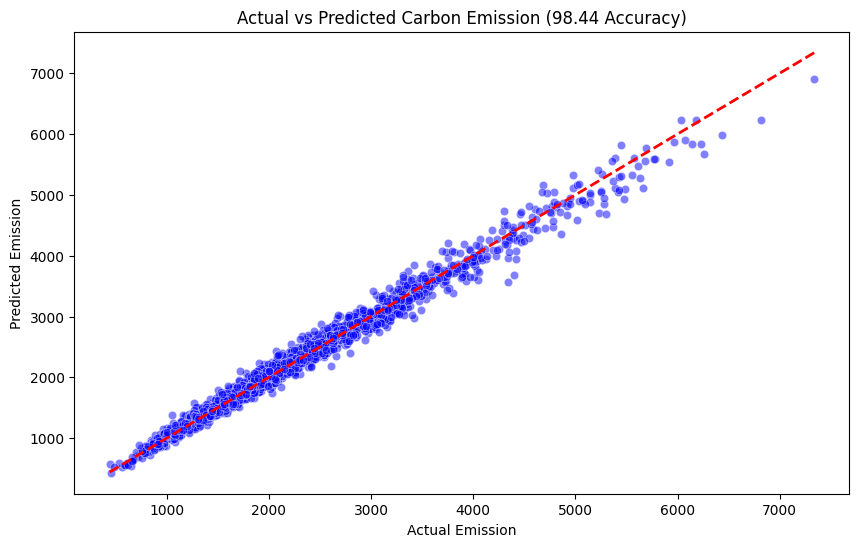

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Emission')
plt.ylabel('Predicted Emission')
plt.title(f'Actual vs Predicted Carbon Emission ({r2_score(y_test, y_pred)*100:.2f} Accuracy)')
plt.show()

In [19]:
def predict_my_emission(user_data):
    
    df_user = pd.DataFrame([user_data])
    df_user = df_user[X.columns]

    for col in encoders:
        df_user[col] = df_user[col].astype(str).str.lower().str.strip()
        known_vals = list(encoders[col].classes_)
        df_user[col] = df_user[col].apply(lambda x: x if x in known_vals else known_vals[0])
        df_user[col] = encoders[col].transform(df_user[col])

    prediction = model.predict(df_user)
    return prediction[0]

sample_user = {
    'Body Type': input("Enter Body Type like (overweight, obese, underweight, normal): "), 
    'Sex': input("Enter the Sex Types (female, male): "), 
    'Diet': input("Enter Diet Types (pescatarian, vegetarian, omnivore, vegan): "),
    'How Often Shower': input("Enter How Often Shower Types (daily, less frequently, more frequently, twice a day): "), 
    'Heating Energy Source': input("Enter Heating Energy Source: 4 Types (coal, natural gas, wood, electricity): "),
    'Transport': input("Enter Transport Types (public, walk/bicycle, private): "), 
    'Vehicle Type': input("Enter Vehicle Types (petrol, diesel, hybrid, lpg, electric): "), 
    'Social Activity': input("Enter Social Activity Types (often, never, sometimes): "),
    'Monthly Grocery Bill': int(input("Enter Monthly Grocery Bill Type (Values range from 50 to 299): ")), 
    'Frequency of Traveling by Air': input("Enter Frequency of Traveling by Air Types (frequently, rarely, never, very frequently): "),
    'Vehicle Monthly Distance Km': int(input("Enter Vehicle Monthly Distance Km Type (Value range from 0 to 9999): ")), 
    'Waste Bag Size': input("Enter Waste Bag Size: Types (large, extra large, small, medium): "),
    'Waste Bag Weekly Count': int(input("Enter Waste Bag Weekly Count Types (Values range from 1 to 7): ")), 
    'How Long TV PC Daily Hour': int(input("Enter How Long TV PC Daily Hour Type (Values range from 0 to 24): ")),
    'How Many New Clothes Monthly': int(input("Enter How Many New Clothes Monthly Type (Values range from 0 to 50): ")), 
    'How Long Internet Daily Hour': int(input("Enter How Long Internet Daily Hour Type (Values range from 0 to 24): ")),
    'Energy efficiency': input("Enter Energy efficiency: 3 Types (No, Sometimes, Yes): "), 
    'Recycling': input("Enter Recycling: Types (Inme metal, paper, plastic, glass ke alag-alag combinations hain): "), 
    'Cooking_With': input("Enter Cooking_With Types (Stove, Oven, Microwave, Grill, Airfryer ke combinations): ")
                                        }

result = predict_my_emission(sample_user)

def get_emission_level(emission):
    if emission < 6000:
        return "LOW"
    elif emission < 12000:
        return "MEDIUM"
    else:
        return "HIGH"

def generate_suggestions(user, emission):
    
    level = get_emission_level(emission)
    tips = []

    if level == "HIGH":
        tips.append("Your carbon footprint is HIGH. Major lifestyle changes recommended.")
    elif level == "MEDIUM":
        tips.append("Your carbon footprint is MODERATE. Some improvements can help.")
    else:
        tips.append("Great! Your carbon footprint is LOW. Keep it up!")

    if user['Transport'] == 'private':
        tips.append("Use public transport, carpool or cycling to reduce transport emissions.")

    if user['Vehicle Type'] in ['petrol','diesel']:
        tips.append("Consider switching to electric or hybrid vehicle.")

    if user['Vehicle Monthly Distance Km'] > 300:
        tips.append("Try reducing monthly travel distance or use remote work options.")

    if user['Frequency of Traveling by Air'] in ['frequently','very frequently']:
        tips.append("Air travel has high emissions. Try reducing flights or offset carbon.")

    if user['Diet'] == 'omnivore':
        tips.append("Reduce meat consumption. Plant-based diet reduces emissions by 50%.")

    if user['How Many New Clothes Monthly'] > 10:
        tips.append("Fast fashion increases emissions. Buy fewer, sustainable clothes.")

    if user['How Long TV PC Daily Hour'] > 8:
        tips.append("Reduce screen time to save electricity.")

    if user['Energy efficiency'] == 'no':
        tips.append("⚡ Use energy-efficient appliances (LED, inverter AC, star rated devices).")

    if user['Waste Bag Weekly Count'] > 4:
        tips.append("Try reducing waste and compost organic waste.")

    if 'recycling' not in user['Recycling']:
        tips.append("Start recycling paper, plastic, glass and metal.")

    if 'microwave' not in user['Cooking_With']:
        tips.append("Microwave & airfryer use less energy than stove/oven.")

    return tips

result = predict_my_emission(sample_user)

print(f"\nPredicted Emission: {result:.2f} kg CO2 per year")

print("\nPersonalised Suggestions:")
suggestions = generate_suggestions(sample_user, result)

for tip in suggestions:
    print("-", tip)

Enter Body Type like (overweight, obese, underweight, normal):  underweight
Enter the Sex Types (female, male):  male
Enter Diet Types (pescatarian, vegetarian, omnivore, vegan):  vegetarian
Enter How Often Shower Types (daily, less frequently, more frequently, twice a day):  daily
Enter Heating Energy Source: 4 Types (coal, natural gas, wood, electricity):  electricity
Enter Transport Types (public, walk/bicycle, private):  walk/bicycle
Enter Vehicle Types (petrol, diesel, hybrid, lpg, electric):  electric
Enter Social Activity Types (often, never, sometimes):  often
Enter Monthly Grocery Bill Type (Values range from 50 to 299):  10
Enter Frequency of Traveling by Air Types (frequently, rarely, never, very frequently):  rarely
Enter Vehicle Monthly Distance Km Type (Value range from 0 to 9999):  100
Enter Waste Bag Size: Types (large, extra large, small, medium):  large
Enter Waste Bag Weekly Count Types (Values range from 1 to 7):  15
Enter How Long TV PC Daily Hour Type (Values rang


Predicted Emission: 1192.00 kg CO2 per year

Personalised Suggestions:
- Great! Your carbon footprint is LOW. Keep it up!
- Try reducing waste and compost organic waste.
- Start recycling paper, plastic, glass and metal.
- Microwave & airfryer use less energy than stove/oven.
